<a href="https://colab.research.google.com/github/Nerneri/World_bank_PIP_analysis/blob/Alexandra_branch/Poverty_And_Inequality_Platform_(PIP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Poverty And Inequality Platform Project**



first dataset page. Poverty And Inequality Platform (PIP) : https://datacatalog.worldbank.org/search/dataset/0063646/poverty-and-inequality-platform-pip-percentiles$0

second dataset page. World Bank Country and Lending Groups : https://www.kaggle.com/datasets/taniaj/world-bank-country-and-lending-groups?resource=download$0







In [214]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [215]:
data_path_PIP = '/content/drive/MyDrive/python_project/world_100bin_revised_filtered_2015.csv'
data_path_classification = '/content/drive/MyDrive/python_project/worldbank_classification.csv'

data_PIP = pd.read_csv(data_path_PIP)
data_classification = pd.read_csv(data_path_classification)

# **1. Abstract/Annotation**

This notebook Is dedicated to analysis of “The Poverty and Inequality Platform: Percentiles” dataset. The analysis is based on two datasets, the PIP Percentiles dataset from the World Bank containing welfare distribution data for 152 countries over 1963-2025, and the World Bank Country and Lending Groups dataset providing regional and income group classifications for 218 economies.
We have made 4 hypothesises:
* Inequality ratio has decreased over last decade.
* The median avg_welfare differs significantly between consumption-based and income-based surveys (welfare_type).
* Sub-Saharam Africa has the lowest average welfare compared to other regions.
* The gap between top 10% and bottom 10% welfare has grown over time.

Roles were distributed as follows:
* Alexandra Khaidukova: Dataset description, data cleanup of PIP dataset, descriptive statistics, data transformation, hypothesises check.
* Alisa Narozhnaya: Data cleanup of World Bank Country and Lending Groups dataset, creation of plots, their overview and comparison, hypothesises check.




---



# **2. Dataset description**

### Poverty And Inequality Platform dataset desciption

The Poverty and Inequality Platform: Percentiles (hereafter referred as PIP) reports 100 points ranked according to the consumption or income distribution for country-year survey data available in the World Bank’s Poverty and Inequality Platform. This analysis is based on a shortened version of original dataset with year range 2015-2025 instead of 1963-2025.

Each distribution reports 100 points per country per survey year ranked from the smallest (percentile 1) to the largest (percentile 100) income or consumption. For each income percentile, the database reports the following variables: the average daily per person income or consumption (avg_welfare); the income or consumption value for the upper threshold of the percentile (quantile); the share and total population of the percentile (pop_share, pop); and the share of income or consumption held by each percentile (welfare_share). In addition, the database reports the welfare measure (welfare_type) used in the survey data—income or consumption—and the region covered (reporting_level)—urban, rural, or national. The distributions are available in 2017 or 2021 PPP$ (Purchasing Power Parity).



In [218]:
print(f'Rows:    {data_PIP.shape[0]:,}')
print(f'Columns: {data_PIP.shape[1]}')
display(data_PIP.head(10))

Rows:    78,200
Columns: 10


,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop
0,AGO,2018,national,consumption,1,0.339233,0.01,0.000546,0.441943,314804.9609
1,AGO,2018,national,consumption,2,0.533436,0.01,0.000858,0.596462,314804.9609
2,AGO,2018,national,consumption,3,0.650429,0.01,0.001046,0.702769,314804.9609
3,AGO,2018,national,consumption,4,0.739613,0.01,0.001189,0.783776,314804.9609
4,AGO,2018,national,consumption,5,0.831807,0.01,0.001338,0.865216,314804.9609
5,AGO,2018,national,consumption,6,0.902726,0.01,0.001452,0.942512,314804.9609
6,AGO,2018,national,consumption,7,0.974341,0.01,0.001567,1.010801,314804.9609
7,AGO,2018,national,consumption,8,1.037263,0.01,0.001668,1.067744,314804.9609
8,AGO,2018,national,consumption,9,1.108826,0.01,0.001783,1.147923,314804.9609
9,AGO,2018,national,consumption,10,1.181259,0.01,0.001900,1.218828,314804.9609


In [219]:
data_PIP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78200 entries, 0 to 78199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     78200 non-null  object 
 1   year             78200 non-null  int64  
 2   reporting_level  78200 non-null  object 
 3   welfare_type     78200 non-null  object 
 4   percentile       78200 non-null  int64  
 5   avg_welfare      78200 non-null  float64
 6   pop_share        78200 non-null  float64
 7   welfare_share    78200 non-null  float64
 8   quantile         77418 non-null  float64
 9   pop              78200 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 6.0+ MB


There are missing values in quantile.

Moreover, dtype of country_code, reporting_level and welfare_type is object (types of values are mixed).

We will correct this further in 3. Data cleanup.


In [220]:
print(f"Countries: {data_PIP['country_code'].nunique()}")
print(f"Year range: {data_PIP['year'].min()} – {data_PIP['year'].max()}")
print(f"Reporting levels: {data_PIP['reporting_level'].unique()}")
print(f"Welfare types: {data_PIP['welfare_type'].unique()}")
print(f"Percentiles: {data_PIP['percentile'].min()} – {data_PIP['percentile'].max()}")

Countries: 152
Year range: 2015 – 2025
Reporting levels: ['national' 'urban' 'rural']
Welfare types: ['consumption' 'income']
Percentiles: 1 – 100


### World Bank Country and Lending Groups dataset desciption


Dataset World Bank Country and Lending Groups have 7 columns - a row index (x), country (Economy), country code (Code), region of the country (Region), Income group and Lending category according to World Bank classification for 2026 and Other. The dataset covers 7 unique regions, 4 income group tiers (low income, lower middle income, upper middle income, high income) and 2 lending types (consumption and income) based on 2026 GNI per capita thresholds. It is planned to be merged with the PIP dataset on country code, adding regional and income context to 152 matched economies.

In [221]:
print(f'Rows:    {data_classification.shape[0]:,}')
print(f'Columns: {data_classification.shape[1]}')
data_classification.head(10)

Rows:    218
Columns: 7


,x,Economy,Code,Region,Income group,Lending category,Other
0,1,Afghanistan,AFG,South Asia,Low income,IDA,HIPC
1,2,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD,NaN
2,3,Algeria,DZA,Middle East & North Africa,Upper middle income,IBRD,NaN
3,4,American Samoa,ASM,East Asia & Pacific,Upper middle income,NaN,NaN
4,5,Andorra,AND,Europe & Central Asia,High income,NaN,NaN
5,6,Angola,AGO,Sub-Saharan Africa,Lower middle income,IBRD,NaN
6,7,Antigua and Barbuda,ATG,Latin America & Caribbean,High income,IBRD,NaN
7,8,Argentina,ARG,Latin America & Caribbean,Upper middle income,IBRD,NaN
8,9,Armenia,ARM,Europe & Central Asia,Upper middle income,IBRD,NaN
9,10,Aruba,ABW,Latin America & Caribbean,High income,NaN,NaN


We can notice that Income group and Lending category require renaming.
Moreover, there is no need in having column x, as we already have basic pd indexes. We will also delete 'Lending category' and 'Other', since they are not that important for our analysis, besides having a lot of missing values.

In [222]:
data_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   x                 218 non-null    int64 
 1   Economy           218 non-null    object
 2   Code              218 non-null    object
 3   Region            218 non-null    object
 4   Income group      218 non-null    object
 5   Lending category  163 non-null    object
 6   Other             39 non-null     object
dtypes: int64(1), object(6)
memory usage: 12.1+ KB


Only x(id) have an explicit dtype, we will also correct this later.



In [223]:
print(f"Countries: {data_classification['Economy'].nunique()}")
print(f"Income levels: {data_classification['Income group'].unique()}")
print(f"Lending types: {data_PIP['welfare_type'].unique()}")

Countries: 218
Income levels: ['Low income' 'Upper middle income' 'High income' 'Lower middle income']
Lending types: ['consumption' 'income']




---



# **3. Data cleanup**

<Axes: >

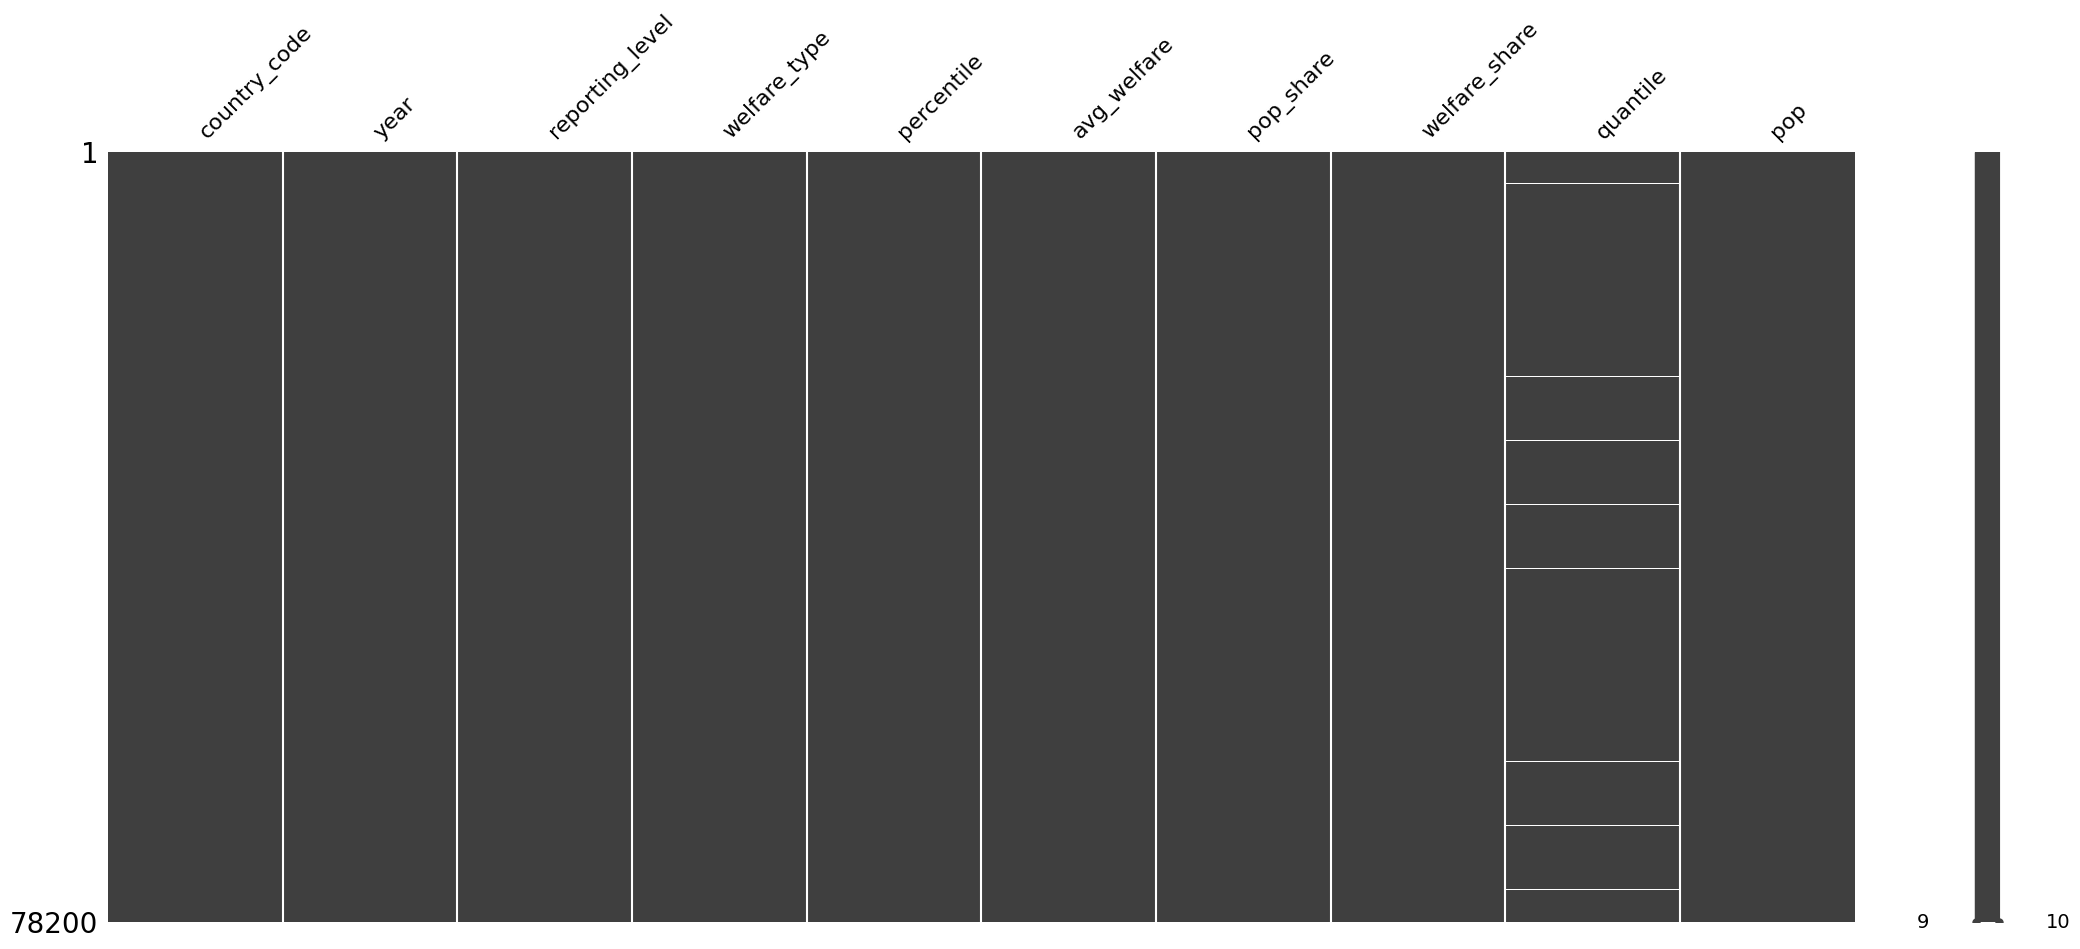

In [224]:
import missingno

missingno.matrix(data_PIP)

In [225]:
data_PIP = data_PIP.dropna(subset=['quantile']).reset_index(drop=True)
data_PIP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77418 entries, 0 to 77417
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     77418 non-null  object 
 1   year             77418 non-null  int64  
 2   reporting_level  77418 non-null  object 
 3   welfare_type     77418 non-null  object 
 4   percentile       77418 non-null  int64  
 5   avg_welfare      77418 non-null  float64
 6   pop_share        77418 non-null  float64
 7   welfare_share    77418 non-null  float64
 8   quantile         77418 non-null  float64
 9   pop              77418 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 5.9+ MB


As country_code, reporting_level and welfare_type does not have missing values, we can just forse their dtype into string:

In [226]:
for col in ['country_code', 'reporting_level', 'welfare_type']:
    data_PIP[col] = data_PIP[col].astype('string')

In [227]:
data_PIP.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77418 entries, 0 to 77417
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     77418 non-null  string 
 1   year             77418 non-null  int64  
 2   reporting_level  77418 non-null  string 
 3   welfare_type     77418 non-null  string 
 4   percentile       77418 non-null  int64  
 5   avg_welfare      77418 non-null  float64
 6   pop_share        77418 non-null  float64
 7   welfare_share    77418 non-null  float64
 8   quantile         77418 non-null  float64
 9   pop              77418 non-null  float64
dtypes: float64(5), int64(2), string(3)
memory usage: 5.9 MB


<Axes: >

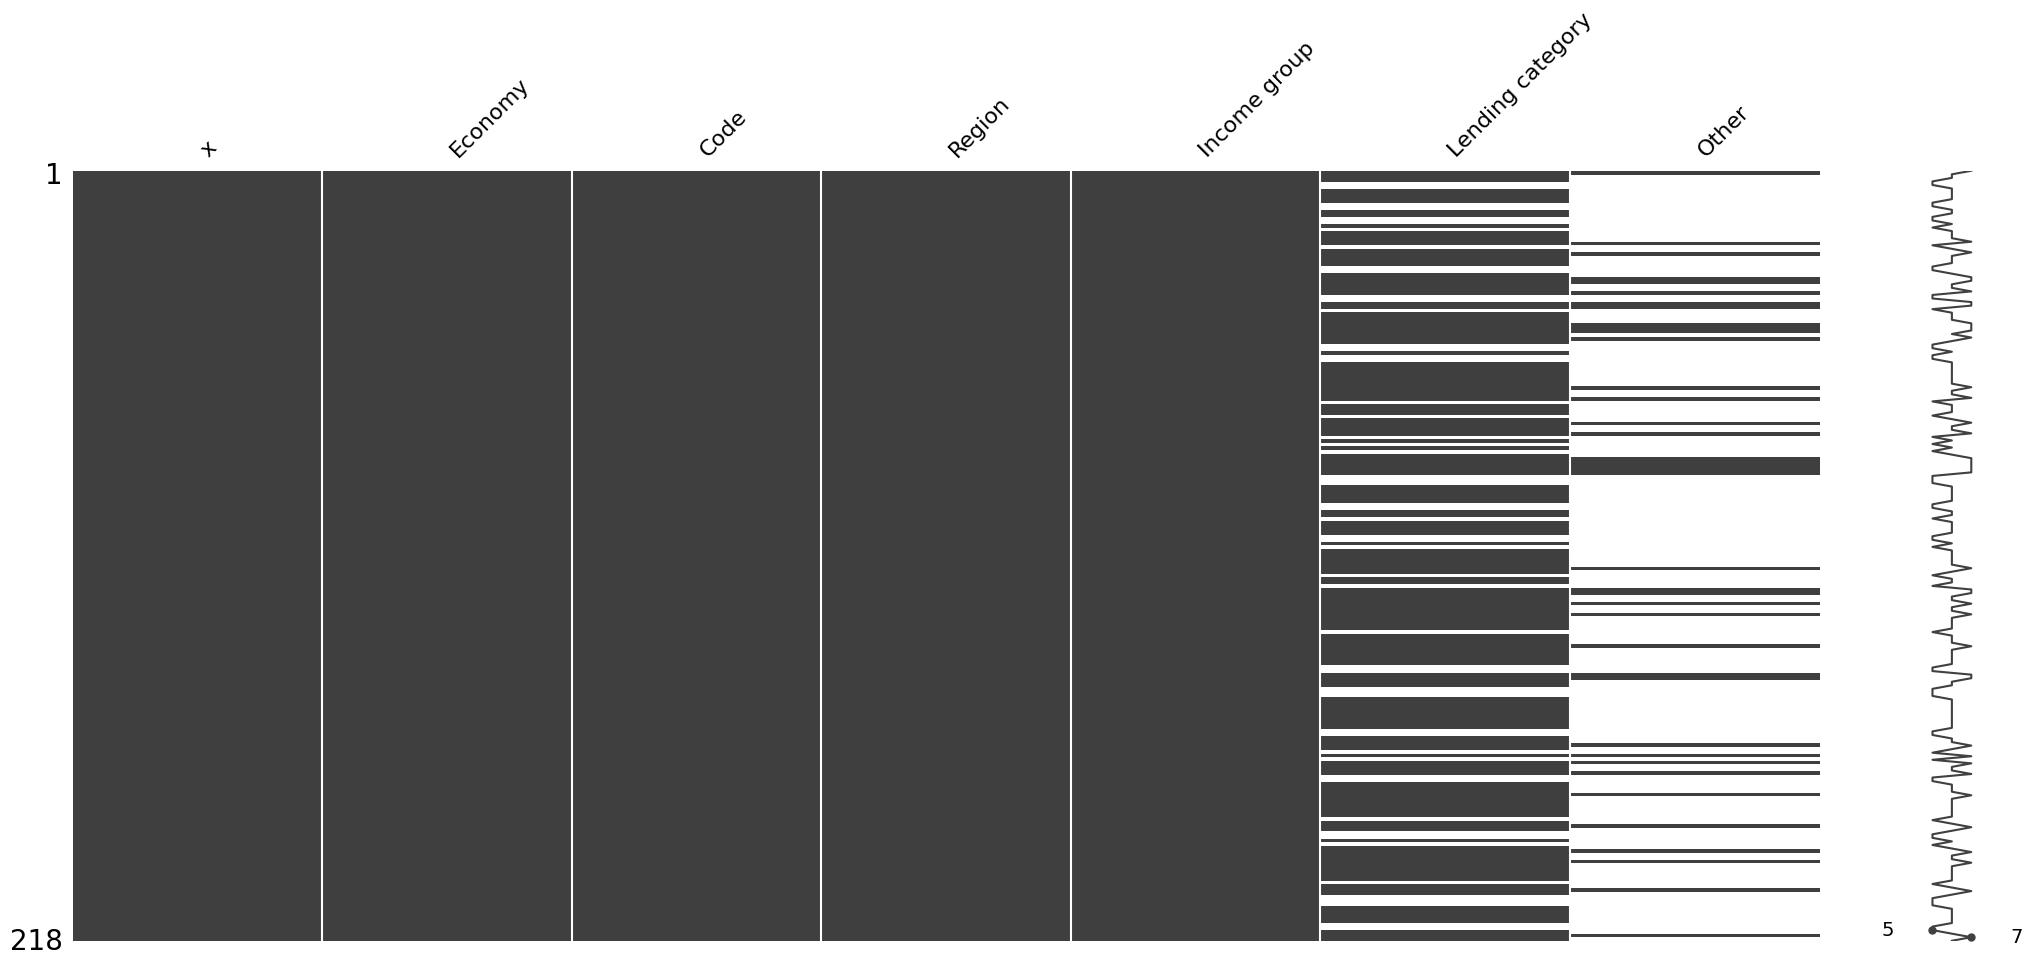

In [228]:
missingno.matrix(data_classification)

Rename columns:

In [230]:
data_classification = data_classification.rename(columns=lambda name: name.lower().replace(' ', '_'))

In [231]:
data_classification.rename(columns={'economy': 'country'}, inplace=True)

In [232]:
for col in ['country', 'code', 'region', 'income_group']:
    data_classification[col] = data_classification[col].astype('string')

In [233]:
data_classification = data_classification.drop(['lending_category', 'other', 'x'], axis = 1).reset_index(drop=True)

In [234]:
data_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       218 non-null    string
 1   code          218 non-null    string
 2   region        218 non-null    string
 3   income_group  218 non-null    string
dtypes: string(4)
memory usage: 6.9 KB




---



# *. Creation of new dataset

Now we can create new dataset with regions instead of countries. Intersection of two datasets on the number of countries is right - all 152 countries from PIP dataset are in classification dataset.
Then we will remove dublicate of code and sort it by region:

In [235]:
pip_codes = set(data_PIP['country_code'].unique())
class_codes = set(data_classification['code'].unique())
print(len(pip_codes))
print(len(class_codes))
print(len(pip_codes & class_codes))

152
218
152


In [236]:
data_PIP_wregion = data_PIP.merge(data_classification, left_on = 'country_code',
                                 right_on = 'code', how='left')
data_PIP_wregion = data_PIP_wregion.drop(['code'], axis = 1)
data_PIP_wregion = data_PIP_wregion.sort_values('year').reset_index(drop =True)

In [237]:
data_PIP_wregion.head()

,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop,country,region,income_group
0,MNE,2015,national,income,24,7.947066,0.01,0.004490,8.052718,6246.51,Montenegro,Europe & Central Asia,Upper middle income
1,MNE,2015,national,income,12,4.959113,0.01,0.002802,5.100096,6246.51,Montenegro,Europe & Central Asia,Upper middle income
2,MNE,2015,national,income,13,5.244522,0.01,0.002963,5.370911,6246.51,Montenegro,Europe & Central Asia,Upper middle income
3,MNE,2015,national,income,14,5.506111,0.01,0.003111,5.691999,6246.51,Montenegro,Europe & Central Asia,Upper middle income
4,MNE,2015,national,income,15,5.843904,0.01,0.003302,6.020383,6246.51,Montenegro,Europe & Central Asia,Upper middle income




---



# **5. Descriptive statistics**

In [238]:
NUMERIC = ['avg_welfare', 'pop_share', 'welfare_share', 'pop']
data_PIP_wregion[NUMERIC].describe().round(2)

,avg_welfare,pop_share,welfare_share,pop
count,77418.00,77418.00,77418.00,77418.00
mean,30.27,0.01,0.01,667487.64
std,32.20,0.00,0.01,1843836.69
min,0.28,0.01,0.00,433.56
25%,8.28,0.01,0.01,44587.59
50%,18.76,0.01,0.01,106849.88
75%,41.65,0.01,0.01,477928.04
max,384.83,0.01,0.07,14327581.15


Below we can see balance across income groups - how many entries belong to each group:

In [239]:
data_PIP_wregion['income_group'].value_counts()

,count
income_group,
High income,32076
Upper middle income,28017
Lower middle income,12969
Low income,4356


Same as above, but in percentage:

In [240]:
data_PIP_wregion['income_group'].value_counts(normalize=True)

,proportion
income_group,
High income,0.414322
Upper middle income,0.361893
Lower middle income,0.167519
Low income,0.056266


Standart deviation of pop_share and welfare_share are minimal (0.00 and 0.01 respectevely), which implies that population and welfare shares are very evenly distributed across percentiles. This was expected, as by dataset design each row represents exactly one percentile.

In contrast, for averge welfare deviation is 32.20, whereas for population is 1843836.69. So in this situation, there is large difference in welfare levels between countries and percentiles. Hight std for pop is expected, since population varies enourmasly (for example population of India or China is much bigger than population of small islands, for example Marshall islands).

In [241]:
data_PIP_wregion[NUMERIC].std().round(2)

,0
avg_welfare,32.20
pop_share,0.00
welfare_share,0.01
pop,1843836.69


Variance confirm same pattern, as in std, but in squared units:

In [242]:
data_PIP_wregion[NUMERIC].var().round(2)

,0
avg_welfare,1.036690e+03
pop_share,0.000000e+00
welfare_share,0.000000e+00
pop,3.399734e+12


North America has the highest mean welfare (78.79) followed by Europe & Central Asia (38.70) and Middle East & North Africa (30.50). South Asia (9.81) and Sub-Saharan Africa (5.36) have the lowest mean welfare highlighting the extreme global welfare gap.
The difference between mean and median avg_welfare within each region indicates skewness. In other words, some wealthy countries pull the regional mean above the median. Larger the difference is - the larger the internal inequality within the region.

Standard deviation of avg_welfare is highest in North America (55.04) and Middle East & North Africa (31.94), meaning these regions have the most internally diverse welfare levels. Sub-Saharan Africa despite having the lowest mean also has relatively low std (5.94), suggesting countries in the region are more overall poor rather than having large internal differences.

In [243]:
data_PIP_wregion.groupby('region')[NUMERIC].agg(['mean', 'median', 'std']).round(2)

avg_welfare               pop_share              \
                                  mean median    std      mean median  std   
region                                                                       
East Asia & Pacific              21.70  12.17  24.64      0.01   0.01  0.0   
Europe & Central Asia            38.70  29.09  33.80      0.01   0.01  0.0   
Latin America & Caribbean        20.08  14.21  19.15      0.01   0.01  0.0   
Middle East & North Africa       30.50  17.54  31.94      0.01   0.01  0.0   
North America                    78.79  64.83  55.04      0.01   0.01  0.0   
South Asia                        9.81   7.16   7.84      0.01   0.01  0.0   
Sub-Saharan Africa                5.36   3.61   5.94      0.01   0.01  0.0   

                           welfare_share                      pop              \
                                    mean median   std        mean      median   
region                                                                          
East Asia & Pacific                 0.01   0.01  0.01  3046290.43  1053129.92   
Europe & Central Asia               0.01   0.01  0.01   219649.65    70953.83   
Latin America & Caribbean           0.01   0.01  0.01   332272.98   112307.34   
Middle East & North Africa          0.01   0.01  0.01   350976.72    92809.00   
North America                       0.01   0.01  0.01  2002444.90  3230842.30   
South Asia                          0.01   0.01  0.01  1953358.51   297050.25   
Sub-Saharan Africa                  0.01   0.01  0.01   300959.40   164099.83   

                                        
                                   std  
region                                  
East Asia & Pacific         4148542.48  
Europe & Central Asia        330326.07  
Latin America & Caribbean    538066.04  
Middle East & North Africa   411899.88  
North America               1458541.20  
South Asia                  3699332.71  
Sub-Saharan Africa           448757.75



---



# **6. Data transofrmation**

Create new columns = inequality_ratio, decade and welfare_delta

In [244]:
data_PIP_wregion['inequality_ratio'] = data_PIP_wregion['welfare_share'] / data_PIP_wregion['pop_share']

In [245]:
data_PIP_wregion['decade'] = (data_PIP_wregion['year'] // 10) * 10


In [246]:
data_PIP_wregion = data_PIP_wregion.sort_values(['country_code', 'year', 'percentile'])
data_PIP_wregion['welfare_delta'] = data_PIP_wregion.groupby(
    ['country_code', 'year']
)['avg_welfare'].diff().fillna(0)

In [247]:
data_PIP_wregion.head()

,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop,country,region,income_group,inequality_ratio,decade,welfare_delta
36925,AGO,2018,national,consumption,1,0.339233,0.01,0.000546,0.441943,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.054556,2010,0.000000
26746,AGO,2018,national,consumption,2,0.533436,0.01,0.000858,0.596462,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.085788,2010,0.194203
26747,AGO,2018,national,consumption,3,0.650429,0.01,0.001046,0.702769,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.104603,2010,0.116993
26748,AGO,2018,national,consumption,4,0.739613,0.01,0.001189,0.783776,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.118946,2010,0.089185
26749,AGO,2018,national,consumption,5,0.831807,0.01,0.001338,0.865216,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.133773,2010,0.092194


Create new dataset and bin abg_welfare into 3 categories based on daily welfare per person value:

In [248]:
categorical_welfare = data_PIP_wregion.copy().reset_index(drop=True)

In [249]:

bins = pd.IntervalIndex.from_tuples(
    [(0, 1), (1, 5), (5, np.inf)], closed='left'
)
categorical_welfare['welfare_category'] = pd.cut(categorical_welfare['avg_welfare'], bins)
categorical_welfare['welfare_category'] = categorical_welfare['welfare_category'].cat.rename_categories(
    ['low', 'medium', 'high']
)

In [250]:
mapper = {
    'low' : 0,
    'medium' : 1,
    'high' : 2,
}

In [251]:
print(categorical_welfare['welfare_category'].unique())

['low', 'medium', 'high']
Categories (3, object): ['low' < 'medium' < 'high']


In [252]:
categorical_welfare['welfare_category_ord'] = categorical_welfare['welfare_category'].map(mapper)

This shows inequality ratio (welfare / pop_share), where ratio < 1 means percentile recieves less than its population share, ratio > 1 percentile recieves more than its population share, ratio = 0 indicates perfectly equal distribution of welfare and pop_share.

In [253]:
categorical_welfare.head()

,country_code,year,reporting_level,welfare_type,percentile,avg_welfare,pop_share,welfare_share,quantile,pop,country,region,income_group,inequality_ratio,decade,welfare_delta,welfare_category,welfare_category_ord
0,AGO,2018,national,consumption,1,0.339233,0.01,0.000546,0.441943,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.054556,2010,0.000000,low,0
1,AGO,2018,national,consumption,2,0.533436,0.01,0.000858,0.596462,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.085788,2010,0.194203,low,0
2,AGO,2018,national,consumption,3,0.650429,0.01,0.001046,0.702769,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.104603,2010,0.116993,low,0
3,AGO,2018,national,consumption,4,0.739613,0.01,0.001189,0.783776,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.118946,2010,0.089185,low,0
4,AGO,2018,national,consumption,5,0.831807,0.01,0.001338,0.865216,314804.9609,Angola,Sub-Saharan Africa,Lower middle income,0.133773,2010,0.092194,low,0




---



# **7. Plots**

1. Histogram. Distribution of Average Welfare.

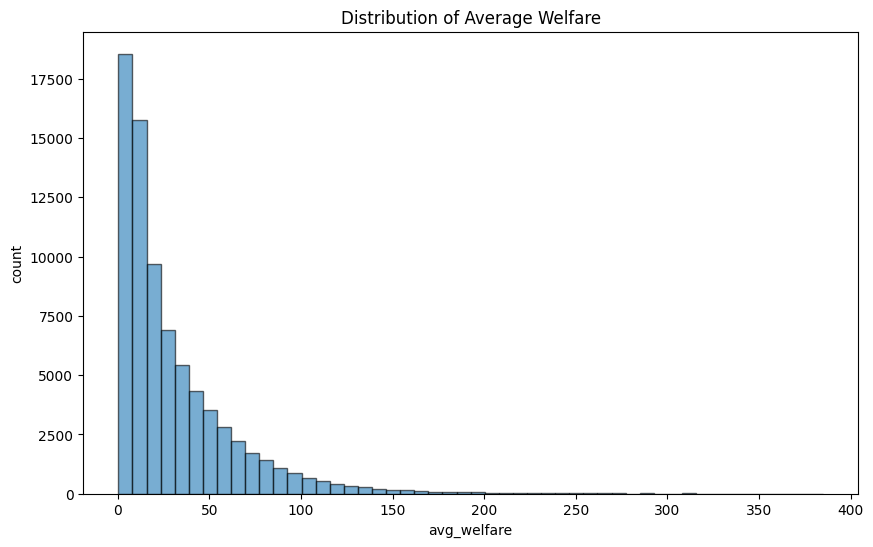

In [254]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data_PIP_wregion['avg_welfare'], bins=50, edgecolor='black', alpha=0.6)
ax.set_title('Distribution of Average Welfare')
ax.set_xlabel('avg_welfare')
ax.set_ylabel('count')
plt.show()

2. Line plot. Average Welfare Over Time.

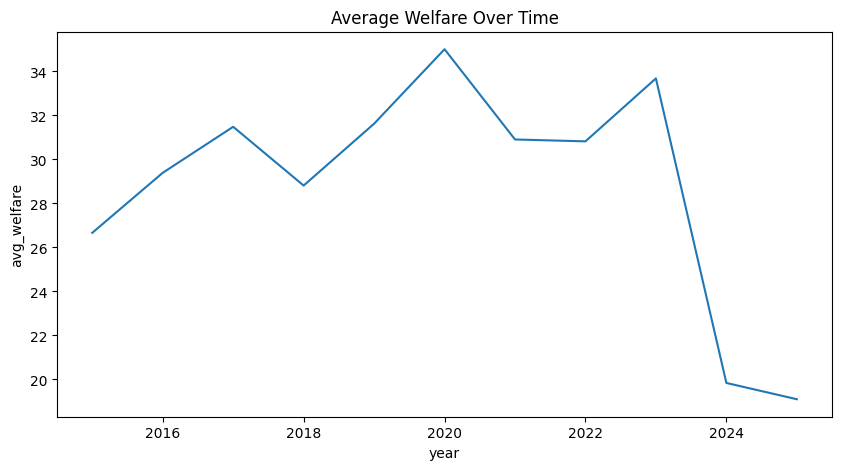

In [255]:
data_PIP_wregion.groupby('year')['avg_welfare'].mean().plot(figsize=(10,5), title='Average Welfare Over Time')
plt.ylabel('avg_welfare')
plt.show()

3. Scatter Plot. Average Welfare vs Inequality Ratio.

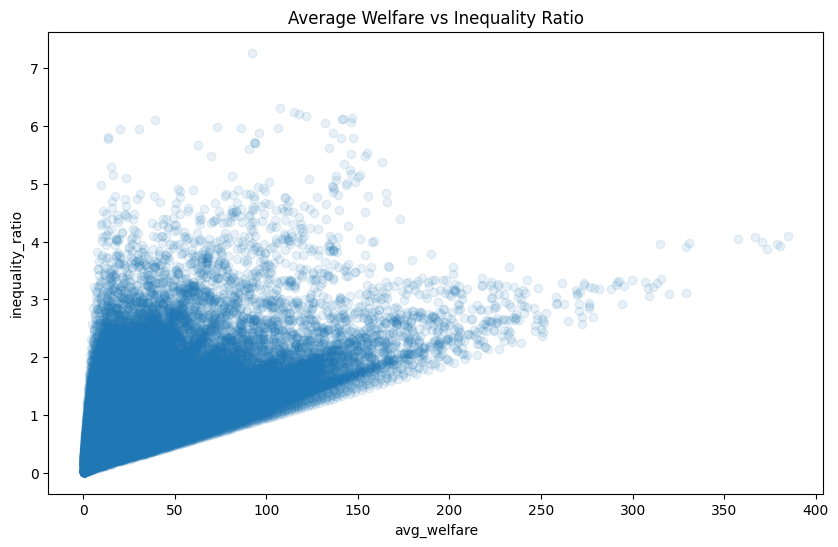

In [256]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(data_PIP_wregion['avg_welfare'], data_PIP_wregion['inequality_ratio'], alpha=0.1)
ax.set_title('Average Welfare vs Inequality Ratio')
ax.set_xlabel('avg_welfare')
ax.set_ylabel('inequality_ratio')
plt.show()

4. Boxplot. Average Welfare by Income Group


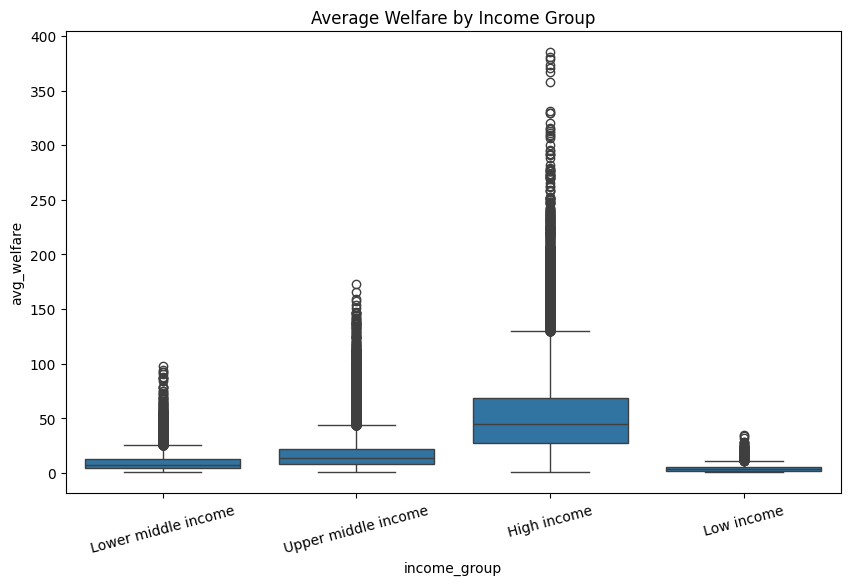

In [257]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=data_PIP_wregion, x='income_group', y='avg_welfare', ax=ax)
ax.set_title('Average Welfare by Income Group')
plt.xticks(rotation=15)
plt.show()



---




# **8. Detailed overview**

Comparing Plot 1. Average Welfare by Region Over Time.

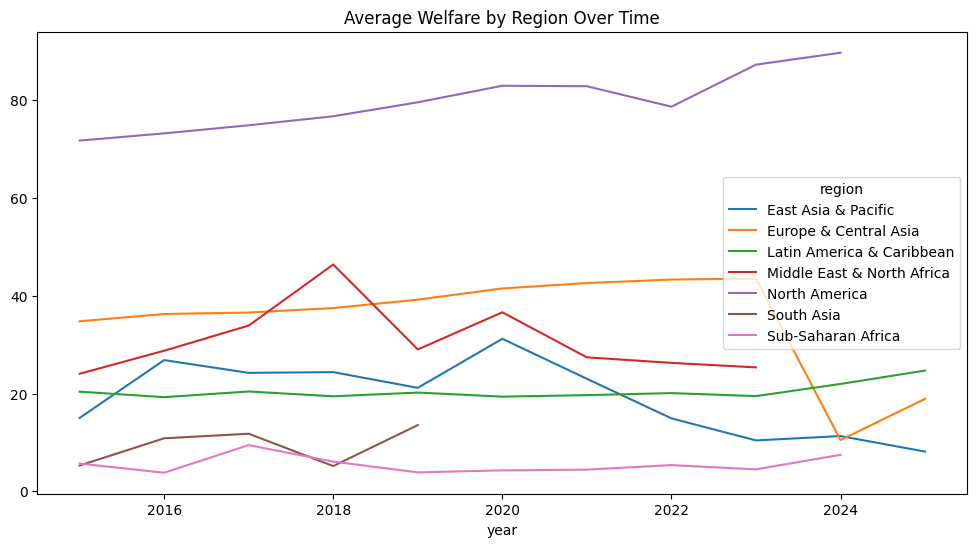

In [258]:
data_PIP_wregion.groupby(['year', 'region'])['avg_welfare'].mean().unstack().plot(figsize=(12, 6))
plt.title('Average Welfare by Region Over Time')
plt.show()

Comparing plot 2. Top 10% vs bottom 10% Welfare Over Time.

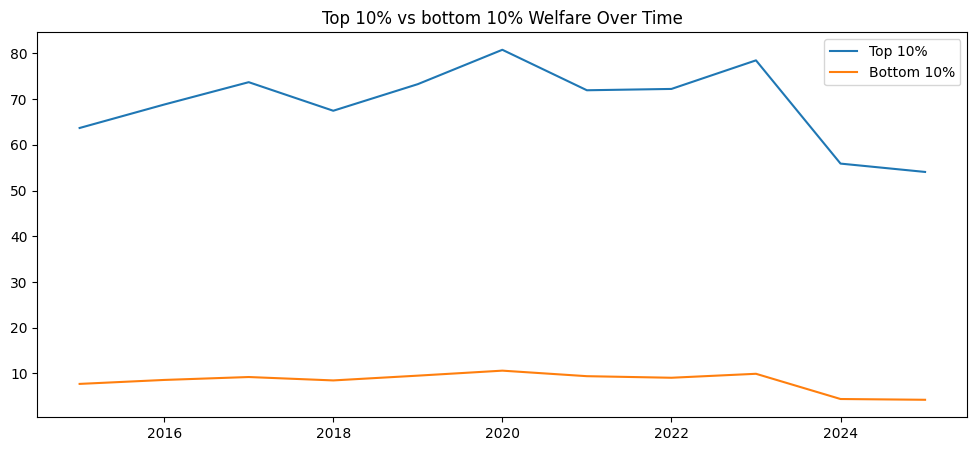

In [259]:
top10 = data_PIP_wregion[data_PIP_wregion['percentile'] >= 90].groupby('year')['avg_welfare'].mean()
bot10 = data_PIP_wregion[data_PIP_wregion['percentile'] <= 10].groupby('year')['avg_welfare'].mean()
plt.figure(figsize=(12,5))
plt.plot(top10, label='Top 10%')
plt.plot(bot10, label='Bottom 10%')
plt.legend()
plt.title('Top 10% vs bottom 10% Welfare Over Time')
plt.show()

Comparing plot 3. Inequality Ratio by Income Group and Decade

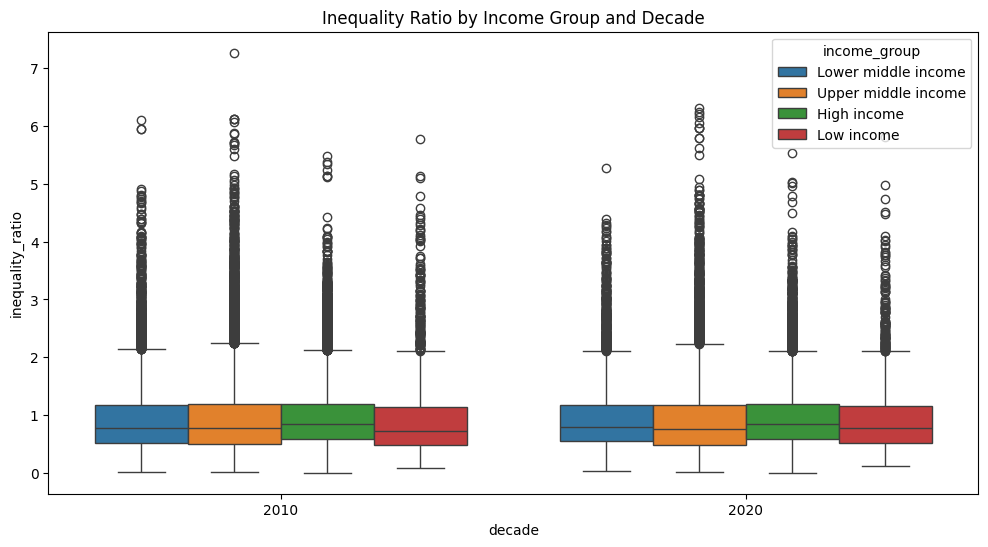

In [260]:
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=data_PIP_wregion, x='decade', y='inequality_ratio', hue='income_group', ax=ax)
ax.set_title('Inequality Ratio by Income Group and Decade')
plt.show()

Comparing plot 4. Welfare Share vs Pop Share by Region

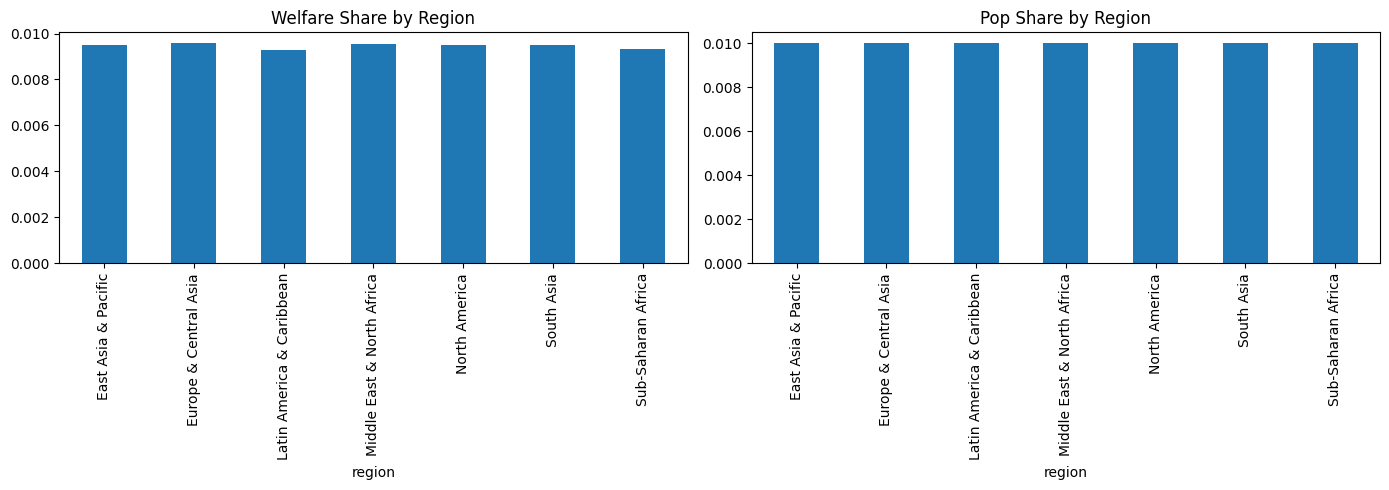

In [261]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
data_PIP_wregion.groupby('region')['welfare_share'].mean().plot(kind='bar', ax=ax1, title='Welfare Share by Region')
data_PIP_wregion.groupby('region')['pop_share'].mean().plot(kind='bar', ax=ax2, title='Pop Share by Region')
plt.tight_layout()
plt.show()



---



# **9. Hypothesis check**